**Module vidéo :**

**Import :**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Keras / TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Masking, LSTM, Dropout, Dense
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# Visualisation des matrices de confusion
import seaborn as sns

# Barre de progression
from tqdm import tqdm

DATA_DIR = Path('./lsfb_data')

**Liens DATA :**

In [3]:
instances = "/Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/lsfb_data/instances.csv"
instances_special = "/Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/lsfb_data/instances_special.csv"
sign_occurences = '/Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/lsfb_data/metadata/sign_occurrences.csv'
sign_to_index = '/Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/lsfb_data/metadata/sign_to_index.csv'



In [4]:
data_instances = pd.read_csv(instances)
data_instances.head(100)

,id,sign,signer,start,end
0,CLSFBI0103A_S001_B_251203_251361,MOI-MEME,S001,251203,251361
1,CLSFBI0103A_S001_B_251516_252209,SENTIR,S001,251516,252209
2,CLSFBI0103A_S001_B_285772_285869,NON.N,S001,285772,285869
3,CLSFBI0103A_S001_B_286114_286297,MAISON,S001,286114,286297
4,CLSFBI0103A_S001_B_286621_286862,DIFFERENT,S001,286621,286862
...,...,...,...,...,...
95,CLSFBI0103A_S001_B_335284_335675,MAMAN.HANCHE,S001,335284,335675
96,CLSFBI0103A_S001_B_335772_335949,PAS.MENTON,S001,335772,335949
97,CLSFBI0103A_S001_B_336021_336309,INTERESSANT,S001,336021,336309
98,CLSFBI0103A_S001_B_336464_336988,ECRIRE,S001,336464,336988


In [5]:
data_instances_special = pd.read_csv(instances_special)
data_instances_special.head(100)

,id,sign,signer,start,end
0,CLSFBI0103A_S001_B_251377_251488,PT:PRO2,S001,251377,251488
1,CLSFBI0103A_S001_B_252353_252691,PT:POSS2,S001,252353,252691
2,CLSFBI0103A_S001_B_283902_285174,PT:PRO2,S001,283902,285174
3,CLSFBI0103A_S001_B_285448_285699,LBUOY,S001,285448,285699
4,CLSFBI0103A_S001_B_286406_286613,PT:PRO1,S001,286406,286613
...,...,...,...,...,...
95,CLSFBI0103A_S001_B_442792_442980,PT:PRO1,S001,442792,442980
96,CLSFBI0103A_S001_B_444456_444789,PT:PRO4,S001,444456,444789
97,CLSFBI0103A_S001_B_448466_448707,PT:PRO1,S001,448466,448707
98,CLSFBI0103A_S001_B_450086_450183,PT:PRO1,S001,450086,450183


In [6]:
data_sign_occurences = pd.read_csv(sign_occurences)
data_sign_occurences.head(100)

,sign,occurrences
0,AUSSI,3308
1,LS,2984
2,OUI,2318
3,AVOIR,1546
4,SOURD,1443
...,...,...
95,COMMENCER,221
96,MOT,221
97,BELLE,218
98,TOUT,218


In [7]:
data_sign_to_index = pd.read_csv(sign_to_index)
data_sign_to_index.head(100)

,sign,class
0,AUSSI,0
1,LS,1
2,OUI,2
3,AVOIR,3
4,SOURD,4
...,...,...
95,COMMENCER,95
96,MOT,96
97,BELLE,97
98,TOUT,98


**Je veux récuperer mes signes pour faire la phrase d'introduction :**

In [8]:
mes_signes = ['BONJOUR', 'MERCI', 'MOI', 'MOI-MEME', 'SOURD', 'AMI', 'PROJET', 'AVEC', 'AIDER', 'COMPRENDRE', 'ENSEMBLE', 'AUJOURD-HUI', 'CONTENT', 'PARLER', 'AVOIR']
data_sign_occurences[data_sign_occurences['sign'].isin(mes_signes)]

,sign,occurrences
3,AVOIR,1546
4,SOURD,1443
21,AUJOURD-HUI,657
23,COMPRENDRE,607
47,PARLER,391
75,AVEC,269
129,AMI,172
132,AIDER,170
210,MOI-MEME,110
235,CONTENT,95


**Le moi est remplacé par moi-même.**

**On valide les signes par rapport au texte qu'on veut dire :**

In [9]:
mes_signes = [
    'AVOIR', 'SOURD', 'AUJOURD-HUI', 'COMPRENDRE', 'PARLER', 'AVEC',
    'AMI', 'AIDER', 'MOI-MEME', 'CONTENT', 'MERCI', 'ENSEMBLE', 'BONJOUR'
]

**Filtrage du dataset sur nos 13 signes :**

**Le dataset complet contient 120 740 instances réparties sur 4 657 signes différents.**

**Pour notre v1, on garde uniquement les 13 signes qui composent notre phrase de présentation :
BONJOUR, AUJOURD-HUI, MOI-MEME, CONTENT, AVEC, AMI, AVOIR, SOURD, AIDER, COMPRENDRE, PARLER, ENSEMBLE, MERCI**

In [10]:
my_instances = data_instances[data_instances['sign'].isin(mes_signes)]

In [11]:
print(f'Dataset complet : {len(data_instances)} lignes')
print(f'Mes instances   : {len(my_instances)} lignes')
print(f'\nRépartition par signe :')
print(my_instances['sign'].value_counts())

Dataset complet : 120739 lignes
Mes instances   : 5652 lignes

Répartition par signe :
sign
AVOIR          1546
SOURD          1443
AUJOURD-HUI     657
COMPRENDRE      607
PARLER          391
AVEC            269
AMI             172
AIDER           170
MOI-MEME        110
CONTENT          95
MERCI            72
ENSEMBLE         67
BONJOUR          53
Name: count, dtype: int64


**On vérifie ou sont les données :**

In [12]:
list(DATA_DIR.iterdir())

[PosixPath('lsfb_data/poses'),
 PosixPath('lsfb_data/.DS_Store'),
 PosixPath('lsfb_data/instances.csv'),
 PosixPath('lsfb_data/instances_special.csv'),
 PosixPath('lsfb_data/metadata')]

**Exploration du dossier poses:**

Le dossier `lsfb_data/poses/` contient les **landmarks pré-extraits** par l'équipe de l'Université de Namur. C'est ce qui nous évite d'avoir à faire tourner MediaPipe sur des heures de vidéo nous-mêmes.

Les chercheurs ont divisé les landmarks en **4 catégories** :

In [13]:
poses_dir = DATA_DIR / 'poses'
print(f'Sous-dossiers dans poses/ :')
for item in poses_dir.iterdir():
    print(f'  {item.name}')

Sous-dossiers dans poses/ :
  face
  right_hand
  pose
  left_hand


**Format de stockage des landmarks (on garde les ID):**

Les fichiers sont nommés avec l'`id` de l'instance, exactement comme dans le CSV.

    exemple : `CLSFBI0402A_S009_B_73138_73624.npy`. Cet identifiant est notre clé de jointure entre les métadonnées (le CSV) et les vraies données (les `.npy`).

In [14]:
left_hand_dir = poses_dir / 'left_hand'  
echantillon = list(left_hand_dir.iterdir())[:5]
for f in echantillon:
    print(f.name)

CLSFBI0402A_S009_B_73138_73624.npy
CLSFBI4404A_S090_B_16763_17329.npy
CLSFBI3204A_S066_B_380557_381050.npy
CLSFBI1914A_S041_B_263625_263895.npy
CLSFBI3014A_S062_B_87605_88653.npy


**Chargement d'un exemple — comprendre la structure :**

- Le 1er chiffre = nombre de **frames** (durée du signe dans le temps)
- Le 2ème chiffre = nombre de **points clés** (21 pour une main, plus pour le visage…)
- Le 3ème chiffre = **coordonnées par point** (probablement 3 : x, y, z)

Une fois ces 3 chiffres connus, on saura quelle architecture de modèle utiliser et comment formater notre `X`.


In [15]:
exemple_id = my_instances.iloc[0]['id']
print(f'ID choisi : {exemple_id}')
print(f'Signe : {my_instances.iloc[0]["sign"]}')

# Charger le fichier de la main droite (par exemple)
fichier_main = poses_dir / 'right_hand' / f'{exemple_id}.npy'
print(f'\nFichier : {fichier_main}')
print(f'Existe : {fichier_main.exists()}')

if fichier_main.exists():
    landmarks = np.load(fichier_main)
    print(f'Shape : {landmarks.shape}')
    print(f'Type : {landmarks.dtype}')

ID choisi : CLSFBI0103A_S001_B_251203_251361
Signe : MOI-MEME

Fichier : lsfb_data/poses/right_hand/CLSFBI0103A_S001_B_251203_251361.npy
Existe : True
Shape : (12, 21, 3)
Type : float16


**Choix : on utilise uniquement les mains pour la v1**

Le dataset contient 4 catégories de landmarks (`pose`, `left_hand`, `right_hand`, `face`). 
Pour ce premier modèle, on se limite **aux deux mains**.

**On définit la fonction :**

In [16]:
def load_hands(instance_id):
    
    # 1. Charger les deux fichiers .npy
    left_path = poses_dir / 'left_hand' / f'{instance_id}.npy'
    right_path = poses_dir / 'right_hand' / f'{instance_id}.npy'
    
    left = np.load(left_path)   
    right = np.load(right_path)              
    
    # 2. Aplatir 21 points × 3 coords → 63 features par frame
    
    left_flat = left.reshape(left.shape[0], -1)   
    right_flat = right.reshape(right.shape[0], -1)
    
    # 3. Concaténer côte à côte sur l'axe des features
    both_hands = np.concatenate([left_flat, right_flat], axis=1)
    
    # 4. Convertir en float32
    both_hands = both_hands.astype(np.float32)
    
    return both_hands

**On test :** 

In [17]:
test_id = my_instances.iloc[0]['id']
result = load_hands(test_id)
print(f'Shape obtenue : {result.shape}')
print(f'Type : {result.dtype}')

Shape obtenue : (12, 126)
Type : float32


In [20]:
from tqdm import tqdm

# Mapping : nom de signe → numéro de classe
mes_signes_list = sorted(my_instances['sign'].unique())
sign_to_idx = {sign: i for i, sign in enumerate(mes_signes_list)}
print(f'Mapping : {sign_to_idx}\n')

X = []
y = []
errors_empty = 0

for _, row in tqdm(my_instances.iterrows(), total=len(my_instances), desc='Chargement landmarks'):
    try:
        landmarks = load_hands(row['id'])
        if landmarks.shape[0] == 0:
            errors_empty += 1
            continue
        label = sign_to_idx[row['sign']]
        X.append(landmarks)
        y.append(label)
    except ValueError:
        errors_empty += 1

y = np.array(y)

print(f'\n✅ Instances chargées : {len(X)}')
print(f'⚠️  Instances ignorées : {errors_empty}')
print(f'\nForme d\'un exemple : {X[0].shape}')
print(f'\nRépartition des labels :')
print(pd.Series(y).value_counts().sort_index())

Mapping : {'AIDER': 0, 'AMI': 1, 'AUJOURD-HUI': 2, 'AVEC': 3, 'AVOIR': 4, 'BONJOUR': 5, 'COMPRENDRE': 6, 'CONTENT': 7, 'ENSEMBLE': 8, 'MERCI': 9, 'MOI-MEME': 10, 'PARLER': 11, 'SOURD': 12}



Chargement landmarks: 100%|███████████████████████████████████████████████████████| 5652/5652 [00:00<00:00, 7223.12it/s]


✅ Instances chargées : 5634
⚠️  Instances ignorées : 18

Forme d'un exemple : (12, 126)

Répartition des labels :
0      169
1      169
2      657
3      265
4     1542
5       53
6      607
7       95
8       67
9       72
10     110
11     390
12    1438
Name: count, dtype: int64


**Récupérer la longueur (nombre de frames) de chaque instance**

**Distribution des longueurs de signes**

Tous les signes n'ont pas la même durée. Pour entraîner un modèle Keras, on doit **uniformiser** :

- **Padder** les signes courts (ajouter des zéros à la fin)
- **Tronquer** les signes longs (couper après la longueur cible)



Min     : 4 frames
Max     : 237 frames
Médiane : 17 frames
Moyenne : 19.2 frames


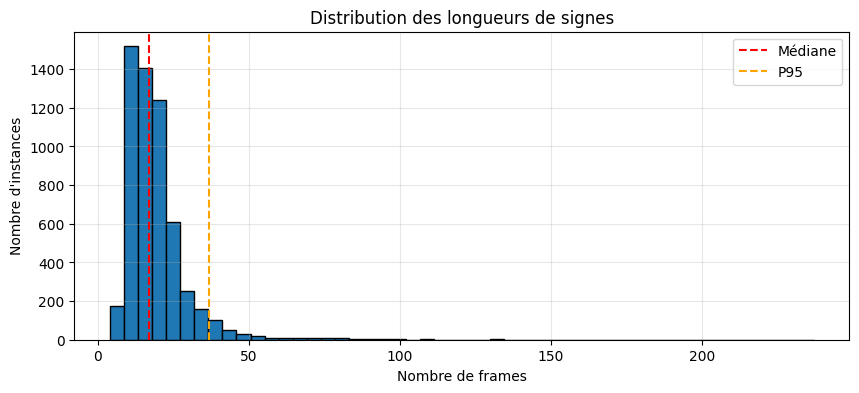

In [22]:
longueurs = [x.shape[0] for x in X]

# Statistiques rapides
print(f'Min     : {min(longueurs)} frames')
print(f'Max     : {max(longueurs)} frames')
print(f'Médiane : {np.median(longueurs):.0f} frames')
print(f'Moyenne : {np.mean(longueurs):.1f} frames')

# Visualiser la distribution
plt.figure(figsize=(10, 4))
plt.hist(longueurs, bins=50, edgecolor='black')
plt.xlabel('Nombre de frames')
plt.ylabel('Nombre d\'instances')
plt.title('Distribution des longueurs de signes')
plt.axvline(np.median(longueurs), color='red', linestyle='--', label='Médiane')
plt.axvline(np.percentile(longueurs, 95), color='orange', linestyle='--', label='P95')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**On fait le padding**

In [24]:
MAX_FRAMES = 40

# Padding/troncature en une ligne
X_padded = pad_sequences(
    X,
    maxlen=MAX_FRAMES,
    dtype='float32',
    padding='post',    # ajoute les zéros à la fin (pas au début)
    truncating='post', # coupe à la fin (garde le début du signe)
)

print(f'Shape de X_padded : {X_padded.shape}')
print(f'Type : {X_padded.dtype}')


Shape de X_padded : (5634, 40, 126)
Type : float32


**On va faire le modèle maintenant :**

Un **LSTM** est l'architecture standard pour traiter des séquences temporelles : il lit la séquence frame par frame et garde en mémoire les patterns temporels.

**Choix d'architecture :**
- `Input(40, 126)` → 40 frames × 126 features (2 mains × 21 points × 3 coords)
- `Masking` → ignore les frames de padding (zéros ajoutés aux signes courts)
- `LSTM(64)` → extrait un résumé de la séquence en 64 dimensions
- `Dropout(0.3)` → régularisation pour éviter l'overfitting
- `Dense(48, relu)` → couche cachée intermédiaire
- `Dense(13, softmax)` → sortie : une probabilité par signe

**Compilation :**
- `adam` → optimizer standard, performant sans réglage
- `sparse_categorical_crossentropy` → loss pour classification multi-classes avec labels entiers
- `accuracy` → métrique facile à interpréter

In [31]:
model = Sequential([
    Input(shape=(40, 126)),
    Masking(mask_value=0.0),
    LSTM(64),
    Dropout(0.3),
    Dense(48, activation='relu'),
    Dense(13, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 40, 126)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           637 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,653 (205.68 KB)

 Trainable params: 52,653 (205.68 KB)

 Non-trainable params: 0 (0.00 B)

**Préparation à l'entraînement:**

On a maintenant :
- Un **modèle Keras** construit (LSTM 64 + Dense 48 + Dense 13)
- Un **X de forme (5634, 40, 126)** prêt à entrer dans le modèle
- Un **y de 5634 entiers** (les labels 0 à 12)

### Split train / validation

On sépare nos données en deux paquets :
- **Train (80%)** → ce que le modèle voit pour apprendre
- **Validation (20%)** → ce qu'on garde pour mesurer sa vraie performance

In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X_padded, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_val   : {y_val.shape}')

X_train : (4507, 40, 126)
X_val   : (1127, 40, 126)
y_train : (4507,)
y_val   : (1127,)


**Class weights — gérer le déséquilibre:**

Notre dataset est très déséquilibré :

- AVOIR : 1542 exemples (28% du dataset !)
- BONJOUR : 53 exemples (1%)

In [36]:
# Calcul automatique des poids
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

# Conversion en dict (ce que Keras attend) : {classe: poids}
class_weight = {i: w for i, w in enumerate(cw)}

print('Class weights :')
for i, w in class_weight.items():
    sign_name = [k for k, v in sign_to_idx.items() if v == i][0]
    print(f'  {i} ({sign_name:15s}) : {w:.2f}')

Class weights :
  0 (AIDER          ) : 2.57
  1 (AMI            ) : 2.57
  2 (AUJOURD-HUI    ) : 0.66
  3 (AVEC           ) : 1.64
  4 (AVOIR          ) : 0.28
  5 (BONJOUR        ) : 8.25
  6 (COMPRENDRE     ) : 0.71
  7 (CONTENT        ) : 4.56
  8 (ENSEMBLE       ) : 6.42
  9 (MERCI          ) : 5.98
  10 (MOI-MEME       ) : 3.94
  11 (PARLER         ) : 1.11
  12 (SOURD          ) : 0.30


**On entraîne le model**

In [37]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train,                          
    y_train,                          
    validation_data=(X_val, y_val),   
    epochs= 50,                   
    batch_size=32,               
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/50


2026-06-02 15:48:05.937063: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.0679 - loss: 2.5499 - val_accuracy: 0.1783 - val_loss: 2.4945 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.1320 - loss: 2.5237 - val_accuracy: 0.0692 - val_loss: 2.4904 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1314 - loss: 2.5130 - val_accuracy: 0.0861 - val_loss: 2.5496 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1143 - loss: 2.4924 - val_accuracy: 0.0710 - val_loss: 2.4835 - learning_rate: 0.0010
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1101 - loss: 2.5014 - val_accuracy: 0.0905 - val_loss: 2.4863 - learning_rate: 0.0010
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1123 - loss: 2.4951 - val_accuracy: 0.0843 - val_loss: 2.4983 - learning_rate: 0.0010
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.1187 - loss: 2.4987 - val_

## 📊 Résultats v1 — modèle baseline

**Configuration :**
- Features : mains seules (left_hand + right_hand → 126 features par frame)
- Modèle : LSTM(64) + Dense(48) + Dense(13)
- 50 epochs, batch_size=32, class_weight balanced

**Résultats sur le set de validation :**

| Métrique | Valeur |
|---|---|
| Accuracy finale (val) | ~33% |
| Best accuracy (val) | 36% (epoch 47) |
| Loss finale (val) | 1.86 |
| Baseline aléatoire | 7.7% (1/13) |

### Diagnostic

> ⚠️ **Le modèle apprend mais sous-performe.** Il est ~4.5× meilleur que le hasard, ce qui prouve qu'il capture quelque chose. Mais 33% est loin du seuil utilisable pour une démo (cible : 70%+).

**Signaux à noter :**
- ✅ Train et val accuracy proches (35% vs 33%) → **pas d'overfitting**
- ⚠️ Loss qui descend lentement (2.55 → 1.65 en 50 epochs) → le modèle a du mal à apprendre
- ⚠️ ReduceLROnPlateau s'est déclenché 2 fois → plateau atteint malgré les ajustements

### Hypothèses pour la v2

1. **Manque d'info contextuelle** : les mains seules ne suffisent pas. Beaucoup de signes utilisent la position du corps (MOI-MEME pointe la poitrine, COMPRENDRE touche la tête...)
2. **Pas de normalisation** : les coordonnées brutes dépendent de la position de la personne dans le cadre

### Plan d'action v2

- ➕ Ajouter les **landmarks de la pose corporelle** (33 points × 3 = 99 features)
- 🎯 **Normaliser** les coordonnées par rapport à un point de référence (épaules) pour rendre le modèle invariant à la position de la personne

**ON ATTAQUE LA V2 : :)**

In [39]:
exemple_id = my_instances.iloc[0]['id']
pose = np.load(poses_dir / 'pose' / f'{exemple_id}.npy')
print(f'Shape pose : {pose.shape}')
print(f'Type : {pose.dtype}')

Shape pose : (12, 33, 3)
Type : float16


## Ajout de la pose + normalisation (version2)

**Nouveautés par rapport à v1 :**
- Ajout de **7 landmarks de pose** (nez, épaules, coudes, poignets) → 21 features supplémentaires
- **Normalisation** par le centre et la largeur des épaules

**Résultat :** features passent de **126 → 147** par frame, et sont maintenant **invariantes** à :
- La position de la personne dans le cadre (gauche, droite, centre)
- La taille de la personne (grande/petite)
- La distance à la caméra (près/loin)

> C'est comme convertir "main à x=0.5 et nez à x=0.4" en "main à 0.1 à droite du nez". Plus la position absolue n'a d'importance, seules les **positions relatives** comptent.

In [40]:
def load_features(instance_id):
    
    # === ÉTAPE 1 : Charger les 3 fichiers ===
    left_hand = np.load(poses_dir / 'left_hand' / f'{instance_id}.npy').astype(np.float32)
    right_hand = np.load(poses_dir / 'right_hand' / f'{instance_id}.npy').astype(np.float32)
    pose = np.load(poses_dir / 'pose' / f'{instance_id}.npy').astype(np.float32)
    
    # === ÉTAPE 2 : Extraire les 7 landmarks de pose utiles ===
    # Indices : 0=nez, 11=épaule_g, 12=épaule_d, 13=coude_g, 14=coude_d, 15=poignet_g, 16=poignet_d
    POSE_INDICES = [0, 11, 12, 13, 14, 15, 16]
    pose_top = pose[:, POSE_INDICES, :]   # shape (frames, 7, 3)
    
    # === ÉTAPE 3 : Normaliser par les épaules ===
    # On prend les épaules dans pose_top : indice 1 (gauche) et indice 2 (droite) APRÈS le slicing
    left_shoulder = pose_top[:, 1, :]    # shape (frames, 3)
    right_shoulder = pose_top[:, 2, :]   # shape (frames, 3)
    
    # Centre des épaules = point de référence
    center = (left_shoulder + right_shoulder) / 2   # shape (frames, 3)
    
    # Distance entre épaules = échelle de la personne
    shoulder_width = np.linalg.norm(left_shoulder - right_shoulder, axis=1, keepdims=True)
    shoulder_width = np.maximum(shoulder_width, 1e-6)  # évite division par zéro
    
    # Reshape center pour pouvoir soustraire des tableaux (frames, N, 3)
    center_reshaped = center[:, np.newaxis, :]   # shape (frames, 1, 3)
    scale_reshaped = shoulder_width[:, np.newaxis, :]   # shape (frames, 1, 1)
    
    # Normaliser chaque type de landmarks
    left_hand_norm = (left_hand - center_reshaped) / scale_reshaped
    right_hand_norm = (right_hand - center_reshaped) / scale_reshaped
    pose_top_norm = (pose_top - center_reshaped) / scale_reshaped
    
    # === ÉTAPE 4 : Aplatir chaque type ===
    n_frames = left_hand_norm.shape[0]
    left_flat = left_hand_norm.reshape(n_frames, -1)     # (frames, 63)
    right_flat = right_hand_norm.reshape(n_frames, -1)   # (frames, 63)
    pose_flat = pose_top_norm.reshape(n_frames, -1)      # (frames, 21)
    
    # === ÉTAPE 5 : Concaténer ===
    all_features = np.concatenate([left_flat, right_flat, pose_flat], axis=1)   # (frames, 147)
    
    return all_features.astype(np.float32)

In [41]:
test_id = my_instances.iloc[0]['id']
result = load_features(test_id)
print(f'Shape obtenue : {result.shape}')
print(f'Type : {result.dtype}')
print(f'\nMin / Max des valeurs : {result.min():.3f} / {result.max():.3f}')

Shape obtenue : (12, 147)
Type : float32

Min / Max des valeurs : -3.099 / 2.231


In [43]:
X = []
y = []
errors_empty = 0

for _, row in tqdm(my_instances.iterrows(), total=len(my_instances), desc='Chargement v2 (mains + pose)'):
    try:
        features = load_features(row['id'])
        if features.shape[0] == 0:
            errors_empty += 1
            continue
        label = sign_to_idx[row['sign']]
        X.append(features)
        y.append(label)
    except (ValueError, FileNotFoundError):
        errors_empty += 1

y = np.array(y)

print(f'\n Instances chargées : {len(X)}')
print(f'Instances ignorées : {errors_empty}')
print(f'\nForme du 1er exemple : {X[0].shape}')

Chargement v2 (mains + pose): 100%|███████████████████████████████████████████████| 5652/5652 [00:01<00:00, 4612.56it/s]


 Instances chargées : 5634
Instances ignorées : 18

Forme du 1er exemple : (12, 147)


In [44]:
X_padded = pad_sequences(
    X,
    maxlen=40,
    dtype='float32',
    padding='post',
    truncating='post',
)

print(f'Shape de X_padded : {X_padded.shape}')

Shape de X_padded : (5634, 40, 147)


In [45]:
X_train, X_val, y_train, y_val = train_test_split(
    X_padded, y, test_size=0.2, stratify=y, random_state=42,
)
print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')

X_train : (4507, 40, 147)
X_val   : (1127, 40, 147)


In [46]:
model = Sequential([
    Input(shape=(40, 147)),     # ← changé de 126 à 147
    Masking(mask_value=0.0),
    LSTM(64),
    Dropout(0.3),
    Dense(48, activation='relu'),
    Dense(13, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [47]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 40, 147)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        54,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           637 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,029 (226.68 KB)

 Trainable params: 58,029 (226.68 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1,
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1154 - loss: 2.5269 - val_accuracy: 0.1783 - val_loss: 2.3991 - learning_rate: 0.0010
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2097 - loss: 2.2118 - val_accuracy: 0.1970 - val_loss: 2.2627 - learning_rate: 0.0010
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2780 - loss: 2.0121 - val_accuracy: 0.2591 - val_loss: 2.0074 - learning_rate: 0.0010
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3006 - loss: 1.9132 - val_accuracy: 0.3407 - val_loss: 1.9510 - learning_rate: 0.0010
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3730 - loss: 1.8078 - val_accuracy: 0.2919 - val_loss: 1.9756 - learning_rate: 0.0010
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3426 - loss: 1.7206 - val_accuracy: 0.2981 - val_loss: 1.9188 - learning_rate: 0.0010
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3572 - loss: 1.

In [49]:
import json
from pathlib import Path

MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

# Le modèle
model.save(MODEL_DIR / 'signlive_v2.keras')

# Les métadonnées
metadata = {
    'sign_to_idx': {str(k): int(v) for k, v in sign_to_idx.items()},
    'idx_to_sign': {str(i): s for s, i in sign_to_idx.items()},
    'n_classes': len(sign_to_idx),
    'n_features': 147,
    'max_frames': 40,
    'pose_indices': [0, 11, 12, 13, 14, 15, 16],
    'normalization': 'shoulder_center_and_width',
    'best_val_accuracy': None,  # à remplir après
}
with open(MODEL_DIR / 'signlive_v2_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'✅ Modèle sauvegardé : {MODEL_DIR / "signlive_v2.keras"}')

✅ Modèle sauvegardé : models/signlive_v2.keras


In [50]:
pip install mediapipe opencv-python

  Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.8/17.8 MB 21.8 MB/s  0:00:00 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 31.5 MB/s  0:00:01 eta 0:00:010:01:01
Using cached numpy-2.2.6-cp310-cp310-macosx_14_0_arm64.whl (5.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 MB 29.8 MB/s  0:00:019.9 MB/s eta 0:00:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [mediapipe]━ 3/4 [mediapipe]trib-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.2.6 which is incompatible.
Note: you may need to resta

In [51]:
pip install "numpy<2.0"

  Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-macosx_11_0_arm64.whl (14.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [52]:
pip list | grep -E "numpy|opencv|tensorflow|mediapipe"

mediapipe                    0.10.35
numpy                        1.26.4
opencv-contrib-python        4.9.0.80
opencv-python                4.9.0.80
tensorflow                   2.16.2
tensorflow-io-gcs-filesystem 0.37.1
tensorflow-metal             1.2.0
Note: you may need to restart the kernel to use updated packages.
